# DL Lab HW02 - FashionMNIST Controlled Experiments

이 노트북은 `Todo.md`의 문제 1~5를 수행하기 위한 실험 노트북이다.

핵심 원칙은 한 번에 하나의 독립변인만 변경하는 것이다. 지난 과제처럼 모델 구조, activation, learning rate, scheduler, normalization을 동시에 바꾸면 성능 변화의 원인을 분리할 수 없다. 따라서 각 문제에서 다음처럼 통제한다.

| 문제 | 비교 대상 | 고정 조건 |
| --- | --- | --- |
| 문제 1 | Sigmoid vs ReLU | 깊이, hidden dimension, optimizer, learning rate, batch size, data split |
| 문제 2 | No regularization vs Weight decay vs Dropout vs Both | 모델 구조, activation, optimizer, learning rate, data split |
| 문제 3 | SGD vs SGD momentum vs AdaGrad vs Adam | 모델 구조, activation, regularization, learning rate, data split |
| 문제 3 scheduler | Adam vs Adam + scheduler | optimizer, initial learning rate, 모델 구조, data split |
| 문제 2 data size | 5,000 vs 20,000 train samples | 모델 구조, regularization 없음, optimizer, learning rate |


In [1]:
import json
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


BASE_SEED = 42
NUM_WORKERS = 2


def set_global_seed(seed_value: int) -> None:
    random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
project_dir = Path(".")
data_dir = project_dir / "data"
output_dir = project_dir / "results_hw02"
data_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# Keep these flags True for the full assignment run. Turn off only for quick debugging.
RUN_PROBLEM_1 = True
RUN_PROBLEM_2 = True
RUN_PROBLEM_3 = True
RUN_FINAL_MODEL = True

print("Using device:", device)
print("Data directory:", data_dir.resolve())
print("Output directory:", output_dir.resolve())


Using device: cuda
Data directory: /home/ilhyeonchu/Documents/GitHub/DL26/hw02/data
Output directory: /home/ilhyeonchu/Documents/GitHub/DL26/hw02/results_hw02


## 공통 데이터 구성

- FashionMNIST train 60,000장과 test 10,000장을 사용한다.
- 문제 2의 regularization 실험은 train 60,000장 중 클래스당 500장, 총 5,000장만 학습에 사용한다.
- validation은 학습에 쓰지 않는 train split에서 클래스당 1,000장, 총 10,000장을 따로 뽑아 모든 비교 실험에 동일하게 사용한다.
- test set은 원본 10,000장을 그대로 유지한다.


In [2]:
fashion_mnist_mean = (0.2860,)
fashion_mnist_std = (0.3530,)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(fashion_mnist_mean, fashion_mnist_std),
])

train_dataset_full = datasets.FashionMNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transform,
)

targets = torch.as_tensor(train_dataset_full.targets)


def stratified_sample_indices(
    targets_tensor: torch.Tensor,
    samples_per_class: int,
    seed_value: int,
    excluded_indices: set[int] | None = None,
) -> list[int]:
    excluded_indices = excluded_indices or set()
    generator = torch.Generator().manual_seed(seed_value)
    selected: list[int] = []

    for class_id in range(10):
        class_indices = torch.where(targets_tensor == class_id)[0].tolist()
        class_indices = [idx for idx in class_indices if idx not in excluded_indices]
        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Class {class_id} has only {len(class_indices)} available samples."
            )

        permutation = torch.randperm(len(class_indices), generator=generator).tolist()
        selected.extend(class_indices[i] for i in permutation[:samples_per_class])

    shuffle_order = torch.randperm(len(selected), generator=generator).tolist()
    return [int(selected[i]) for i in shuffle_order]


def shuffled_indices(indices: list[int], seed_value: int) -> list[int]:
    generator = torch.Generator().manual_seed(seed_value)
    order = torch.randperm(len(indices), generator=generator).tolist()
    return [indices[i] for i in order]


small_train_indices = stratified_sample_indices(
    targets_tensor=targets,
    samples_per_class=500,
    seed_value=BASE_SEED + 1,
)

validation_indices = stratified_sample_indices(
    targets_tensor=targets,
    samples_per_class=1000,
    seed_value=BASE_SEED + 2,
    excluded_indices=set(small_train_indices),
)

additional_train_indices = stratified_sample_indices(
    targets_tensor=targets,
    samples_per_class=1500,
    seed_value=BASE_SEED + 3,
    excluded_indices=set(small_train_indices) | set(validation_indices),
)
large_train_indices = shuffled_indices(
    small_train_indices + additional_train_indices,
    seed_value=BASE_SEED + 4,
)

full_train_indices = [
    idx for idx in range(len(train_dataset_full)) if idx not in set(validation_indices)
]
full_train_indices = shuffled_indices(full_train_indices, seed_value=BASE_SEED + 5)


def class_count(indices: list[int]) -> dict[int, int]:
    labels = targets[indices].tolist()
    return {class_id: labels.count(class_id) for class_id in range(10)}


def print_split_summary(name: str, indices: list[int]) -> None:
    print(f"{name}: {len(indices):,} samples")
    print(class_count(indices))


print_split_summary("Small train split", small_train_indices)
print_split_summary("Validation split", validation_indices)
print_split_summary("Large train split", large_train_indices)
print(f"Full train split excluding validation: {len(full_train_indices):,} samples")
print(f"Original test split: {len(test_dataset):,} samples")


def make_train_loader(
    indices: list[int],
    batch_size: int,
    shuffle: bool,
    seed_offset: int,
) -> DataLoader:
    generator = torch.Generator().manual_seed(BASE_SEED + seed_offset) if shuffle else None
    return DataLoader(
        Subset(train_dataset_full, indices),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def make_test_loader(batch_size: int) -> DataLoader:
    return DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


100.0%
100.0%
100.0%
100.0%


Small train split: 5,000 samples
{0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Validation split: 10,000 samples
{0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
Large train split: 20,000 samples
{0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000}
Full train split excluding validation: 50,000 samples
Original test split: 10,000 samples


## 공통 모델과 학습 유틸리티

`ControlledMLP`는 모든 문제에서 같은 클래스를 사용한다. 각 실험 config에서 바꾸는 값만 독립변인으로 취급한다.


In [3]:
def get_activation(name: str) -> type[nn.Module]:
    activation_map: dict[str, type[nn.Module]] = {
        "relu": nn.ReLU,
        "sigmoid": nn.Sigmoid,
        "tanh": nn.Tanh,
        "gelu": nn.GELU,
    }
    if name not in activation_map:
        raise ValueError(f"Unsupported activation: {name}")
    return activation_map[name]


class ControlledMLP(nn.Module):
    def __init__(
        self,
        hidden_dims: list[int],
        activation_name: str,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        activation_layer = get_activation(activation_name)
        layers: list[nn.Module] = []
        prev_dim = 28 * 28

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation_layer())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 10))
        self.model = nn.Sequential(*layers)
        self.hidden_dims = hidden_dims
        self.activation_name = activation_name
        self.dropout = dropout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.model(x)

    def linear_layers(self) -> list[nn.Linear]:
        return [module for module in self.model if isinstance(module, nn.Linear)]


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def model_structure_string(hidden_dims: list[int]) -> str:
    dims = [28 * 28] + hidden_dims + [10]
    return " -> ".join(str(dim) for dim in dims)


BASE_HIDDEN_DIMS = [512, 256, 128]
DEEP_HIDDEN_DIMS = [256] * 8

preview_model = ControlledMLP(
    hidden_dims=BASE_HIDDEN_DIMS,
    activation_name="relu",
    dropout=0.0,
)
print("Base model:", model_structure_string(BASE_HIDDEN_DIMS))
print("Trainable parameters:", count_trainable_parameters(preview_model))


Base model: 784 -> 512 -> 256 -> 128 -> 10
Trainable parameters: 567434


In [4]:
criterion = nn.CrossEntropyLoss()


def build_optimizer(
    optimizer_name: str,
    model: nn.Module,
    learning_rate: float,
    weight_decay: float,
    momentum: float = 0.0,
) -> torch.optim.Optimizer:
    if optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=momentum,
            weight_decay=weight_decay,
        )
    if optimizer_name == "adagrad":
        return torch.optim.Adagrad(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )
    if optimizer_name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def build_scheduler(
    scheduler_name: str,
    optimizer: torch.optim.Optimizer,
    epochs: int,
) -> object | None:
    if scheduler_name == "none":
        return None
    if scheduler_name == "cosine":
        return CosineAnnealingLR(optimizer, T_max=epochs)
    raise ValueError(f"Unsupported scheduler: {scheduler_name}")


def weight_gradient_norms(model: ControlledMLP) -> list[float]:
    norms: list[float] = []
    for layer in model.linear_layers():
        if layer.weight.grad is None:
            norms.append(0.0)
        else:
            norms.append(float(layer.weight.grad.detach().norm(2).cpu().item()))
    return norms


def train_one_epoch(
    model: ControlledMLP,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    record_gradients: bool,
) -> tuple[float, float, list[float] | None]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    gradient_sums: list[float] | None = None
    gradient_batches = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        if record_gradients:
            batch_norms = weight_gradient_norms(model)
            if gradient_sums is None:
                gradient_sums = [0.0 for _ in batch_norms]
            for index, value in enumerate(batch_norms):
                gradient_sums[index] += value
            gradient_batches += 1

        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    mean_gradient_norms = None
    if gradient_sums is not None and gradient_batches > 0:
        mean_gradient_norms = [value / gradient_batches for value in gradient_sums]

    return total_loss / len(loader.dataset), correct / total, mean_gradient_norms


def evaluate(model: ControlledMLP, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)

    return total_loss / len(loader.dataset), correct / total


def run_controlled_training(
    name: str,
    config: dict,
    train_indices: list[int],
    val_indices: list[int],
    record_gradients: bool = False,
    data_seed_offset: int = 100,
) -> dict:
    set_global_seed(config.get("model_seed", BASE_SEED))

    train_loader = make_train_loader(
        indices=train_indices,
        batch_size=config["batch_size"],
        shuffle=True,
        seed_offset=data_seed_offset,
    )
    val_loader = make_train_loader(
        indices=val_indices,
        batch_size=config["batch_size"],
        shuffle=False,
        seed_offset=data_seed_offset,
    )
    test_loader = make_test_loader(batch_size=config["batch_size"])

    model = ControlledMLP(
        hidden_dims=config["hidden_dims"],
        activation_name=config["activation"],
        dropout=config.get("dropout", 0.0),
    ).to(device)
    optimizer = build_optimizer(
        optimizer_name=config["optimizer"],
        model=model,
        learning_rate=config["learning_rate"],
        weight_decay=config.get("weight_decay", 0.0),
        momentum=config.get("momentum", 0.0),
    )
    scheduler = build_scheduler(config.get("scheduler", "none"), optimizer, config["epochs"])

    print(f"\n===== {name} =====")
    print("Structure:", model_structure_string(config["hidden_dims"]))
    print("Activation:", config["activation"])
    print("Dropout:", config.get("dropout", 0.0))
    print("Optimizer:", config["optimizer"])
    print("Learning rate:", config["learning_rate"])
    print("Weight decay:", config.get("weight_decay", 0.0))
    print("Scheduler:", config.get("scheduler", "none"))
    print("Trainable parameters:", count_trainable_parameters(model))

    history: list[dict] = []
    best_val_accuracy = -1.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(config["epochs"]):
        train_loss, train_accuracy, gradient_norms = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            record_gradients=record_gradients,
        )
        val_loss, val_accuracy = evaluate(model, val_loader)
        current_lr = optimizer.param_groups[0]["lr"]

        entry = {
            "epoch": epoch + 1,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        }
        if gradient_norms is not None:
            entry["gradient_norms"] = gradient_norms
        history.append(entry)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            best_model_state = deepcopy(model.state_dict())

        print(
            f"[{name}] Epoch {epoch + 1:02d}/{config['epochs']} | "
            f"lr={current_lr:.6f} | "
            f"train_loss={train_loss:.4f}, train_acc={train_accuracy:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_accuracy:.4f}"
        )

        if scheduler is not None:
            scheduler.step()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_loss, test_accuracy = evaluate(model, test_loader)
    result = {
        "name": name,
        "config": deepcopy(config),
        "model_structure": model_structure_string(config["hidden_dims"]),
        "trainable_parameters": count_trainable_parameters(model),
        "history": history,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "test_loss_at_best_val": test_loss,
        "test_accuracy_at_best_val": test_accuracy,
    }
    print(
        f"[{name}] best_epoch={best_epoch}, "
        f"best_val_acc={best_val_accuracy:.4f}, "
        f"test_acc_at_best_val={test_accuracy:.4f}"
    )
    return result


def save_json(data: dict, path: Path) -> None:
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
    print("Saved:", path)


## 문제 1. Deep Architecture 실험

목표: 8층 이상 MLP에서 Sigmoid와 ReLU의 gradient flow를 비교한다.

통제 조건:

- hidden layer 수와 hidden dimension 동일: `784 -> 256 x 8 -> 10`
- optimizer 동일: Adam
- learning rate 동일: 0.001
- epoch, batch size, data split 동일
- 변경 변인은 activation 하나뿐이다.

gradient norm은 각 batch의 backward 직후 `layer.weight.grad.norm(2)`로 계산하고, epoch 단위 평균을 저장한다.


In [5]:
problem1_shared_config = {
    "hidden_dims": DEEP_HIDDEN_DIMS,
    "optimizer": "adam",
    "learning_rate": 0.001,
    "weight_decay": 0.0,
    "dropout": 0.0,
    "scheduler": "none",
    "epochs": 12,
    "batch_size": 256,
    "model_seed": BASE_SEED,
}

problem1_configs = {
    "sigmoid_deep": {
        **problem1_shared_config,
        "activation": "sigmoid",
        "changed_variable": "activation=sigmoid",
    },
    "relu_deep": {
        **problem1_shared_config,
        "activation": "relu",
        "changed_variable": "activation=relu",
    },
}

problem1_results: dict[str, dict] = {}

if RUN_PROBLEM_1:
    for run_name, run_config in problem1_configs.items():
        problem1_results[run_name] = run_controlled_training(
            name=run_name,
            config=run_config,
            train_indices=full_train_indices,
            val_indices=validation_indices,
            record_gradients=True,
            data_seed_offset=100,
        )

    save_json(problem1_results, output_dir / "problem1_deep_activation_results.json")
else:
    print("Problem 1 run is disabled.")



===== sigmoid_deep =====
Structure: 784 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 10
Activation: sigmoid
Dropout: 0.0
Optimizer: adam
Learning rate: 0.001
Weight decay: 0.0
Scheduler: none
Trainable parameters: 664074
[sigmoid_deep] Epoch 01/12 | lr=0.001000 | train_loss=2.0043, train_acc=0.1588 | val_loss=1.7006, val_acc=0.1967
[sigmoid_deep] Epoch 02/12 | lr=0.001000 | train_loss=1.7115, train_acc=0.1978 | val_loss=1.7067, val_acc=0.1989
[sigmoid_deep] Epoch 03/12 | lr=0.001000 | train_loss=1.7300, train_acc=0.1959 | val_loss=1.7242, val_acc=0.1977
[sigmoid_deep] Epoch 04/12 | lr=0.001000 | train_loss=1.7169, train_acc=0.1949 | val_loss=1.6980, val_acc=0.1956
[sigmoid_deep] Epoch 05/12 | lr=0.001000 | train_loss=1.7084, train_acc=0.1990 | val_loss=1.7108, val_acc=0.2001
[sigmoid_deep] Epoch 06/12 | lr=0.001000 | train_loss=1.7337, train_acc=0.1987 | val_loss=1.7809, val_acc=0.1991
[sigmoid_deep] Epoch 07/12 | lr=0.001000 | train_loss=1.7644, train_acc=0.1976 | val_l

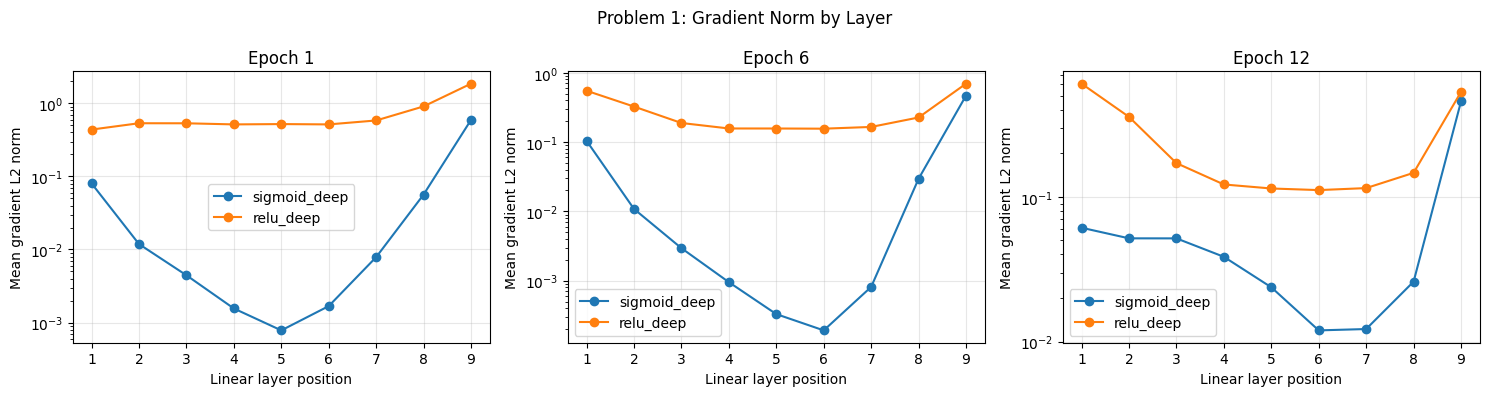

Saved: results_hw02/problem1_summary.json
{
  "sigmoid_deep": {
    "model_structure": "784 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 10",
    "trainable_parameters": 664074,
    "first_hidden_gradient_norm_final_epoch": 0.061212608093581145,
    "last_hidden_gradient_norm_final_epoch": 0.025954057315212428,
    "output_gradient_norm_final_epoch": 0.4570826576376448,
    "first_to_last_hidden_gradient_ratio": 2.3584986096837603,
    "best_val_accuracy": 0.4035,
    "test_accuracy_at_best_val": 0.3968
  },
  "relu_deep": {
    "model_structure": "784 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 256 -> 10",
    "trainable_parameters": 664074,
    "first_hidden_gradient_norm_final_epoch": 0.6063152404159916,
    "last_hidden_gradient_norm_final_epoch": 0.1466304968890487,
    "output_gradient_norm_final_epoch": 0.5317025139015548,
    "first_to_last_hidden_gradient_ratio": 4.1349872862721995,
    "best_val_accuracy": 0.8885,
    "test_accuracy_at_best_val": 0.8833


In [6]:
def plot_problem1_gradient_norms(results: dict[str, dict], selected_epochs: list[int]) -> None:
    if not results:
        print("No Problem 1 results to plot.")
        return

    fig, axes = plt.subplots(1, len(selected_epochs), figsize=(5 * len(selected_epochs), 4))
    if len(selected_epochs) == 1:
        axes = [axes]

    for axis, epoch_number in zip(axes, selected_epochs):
        for run_name, result in results.items():
            history = result["history"]
            if epoch_number > len(history):
                continue
            norms = history[epoch_number - 1]["gradient_norms"]
            layer_positions = list(range(1, len(norms) + 1))
            axis.plot(layer_positions, norms, marker="o", label=run_name)

        axis.set_title(f"Epoch {epoch_number}")
        axis.set_xlabel("Linear layer position")
        axis.set_ylabel("Mean gradient L2 norm")
        axis.set_yscale("log")
        axis.grid(True, alpha=0.3)
        axis.legend()

    fig.suptitle("Problem 1: Gradient Norm by Layer")
    fig.tight_layout()
    fig.savefig(output_dir / "problem1_gradient_norms.png", dpi=150)
    plt.show()


def summarize_problem1(results: dict[str, dict]) -> dict:
    summary: dict[str, dict] = {}
    for run_name, result in results.items():
        final_norms = result["history"][-1]["gradient_norms"]
        first_hidden_norm = final_norms[0]
        last_hidden_norm = final_norms[-2]
        output_norm = final_norms[-1]
        summary[run_name] = {
            "model_structure": result["model_structure"],
            "trainable_parameters": result["trainable_parameters"],
            "first_hidden_gradient_norm_final_epoch": first_hidden_norm,
            "last_hidden_gradient_norm_final_epoch": last_hidden_norm,
            "output_gradient_norm_final_epoch": output_norm,
            "first_to_last_hidden_gradient_ratio": first_hidden_norm / max(last_hidden_norm, 1e-12),
            "best_val_accuracy": result["best_val_accuracy"],
            "test_accuracy_at_best_val": result["test_accuracy_at_best_val"],
        }
    return summary


if RUN_PROBLEM_1 and problem1_results:
    plot_problem1_gradient_norms(problem1_results, selected_epochs=[1, 6, 12])
    problem1_summary = summarize_problem1(problem1_results)
    save_json(problem1_summary, output_dir / "problem1_summary.json")
    print(json.dumps(problem1_summary, indent=2, ensure_ascii=False))

    print("\n분석 가이드")
    print("- Sigmoid에서 앞쪽 layer의 gradient norm이 뒤쪽 layer보다 훨씬 작으면 gradient vanishing으로 해석할 수 있다.")
    print("- ReLU에서 앞쪽 layer의 gradient norm이 Sigmoid보다 크게 유지되면 깊은 네트워크의 gradient 흐름이 개선된 것이다.")


## 문제 2. Regularization 비교 실험

목표: 5,000장 균등 샘플링 학습 환경에서 overfitting을 관찰하고 regularization 효과를 비교한다.

통제 조건:

- train split: 클래스당 500장, 총 5,000장
- validation split: 클래스당 1,000장, 총 10,000장
- test split: 원본 test 10,000장
- 모델 구조 동일: `784 -> 512 -> 256 -> 128 -> 10`
- activation 동일: ReLU
- optimizer 동일: Adam
- learning rate 동일: 0.001
- epoch, batch size 동일

비교 조건:

- No regularization
- Weight decay only
- Dropout only
- Dropout + Weight decay

마지막 조건은 과제의 “동시 적용 결과 비교”를 위해 별도 실험으로 둔다.


In [7]:
problem2_shared_config = {
    "hidden_dims": BASE_HIDDEN_DIMS,
    "activation": "relu",
    "optimizer": "adam",
    "learning_rate": 0.001,
    "scheduler": "none",
    "epochs": 30,
    "batch_size": 128,
    "model_seed": BASE_SEED,
}

problem2_configs = {
    "no_regularization": {
        **problem2_shared_config,
        "dropout": 0.0,
        "weight_decay": 0.0,
        "changed_variable": "none",
    },
    "weight_decay": {
        **problem2_shared_config,
        "dropout": 0.0,
        "weight_decay": 1e-4,
        "changed_variable": "weight_decay=1e-4",
    },
    "dropout": {
        **problem2_shared_config,
        "dropout": 0.3,
        "weight_decay": 0.0,
        "changed_variable": "dropout=0.3",
    },
    "dropout_weight_decay": {
        **problem2_shared_config,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "changed_variable": "dropout=0.3 + weight_decay=1e-4",
    },
}

problem2_results: dict[str, dict] = {}

if RUN_PROBLEM_2:
    for run_name, run_config in problem2_configs.items():
        problem2_results[run_name] = run_controlled_training(
            name=run_name,
            config=run_config,
            train_indices=small_train_indices,
            val_indices=validation_indices,
            record_gradients=False,
            data_seed_offset=200,
        )

    save_json(problem2_results, output_dir / "problem2_regularization_results.json")
else:
    print("Problem 2 run is disabled.")



===== no_regularization =====
Structure: 784 -> 512 -> 256 -> 128 -> 10
Activation: relu
Dropout: 0.0
Optimizer: adam
Learning rate: 0.001
Weight decay: 0.0
Scheduler: none
Trainable parameters: 567434
[no_regularization] Epoch 01/30 | lr=0.001000 | train_loss=0.9886, train_acc=0.6554 | val_loss=0.6107, val_acc=0.7587
[no_regularization] Epoch 02/30 | lr=0.001000 | train_loss=0.5416, train_acc=0.7906 | val_loss=0.5322, val_acc=0.8043
[no_regularization] Epoch 03/30 | lr=0.001000 | train_loss=0.4605, train_acc=0.8290 | val_loss=0.5004, val_acc=0.8154
[no_regularization] Epoch 04/30 | lr=0.001000 | train_loss=0.4290, train_acc=0.8412 | val_loss=0.4860, val_acc=0.8225
[no_regularization] Epoch 05/30 | lr=0.001000 | train_loss=0.4394, train_acc=0.8296 | val_loss=0.5101, val_acc=0.8115
[no_regularization] Epoch 06/30 | lr=0.001000 | train_loss=0.3702, train_acc=0.8580 | val_loss=0.5084, val_acc=0.8193
[no_regularization] Epoch 07/30 | lr=0.001000 | train_loss=0.3559, train_acc=0.8700 | val

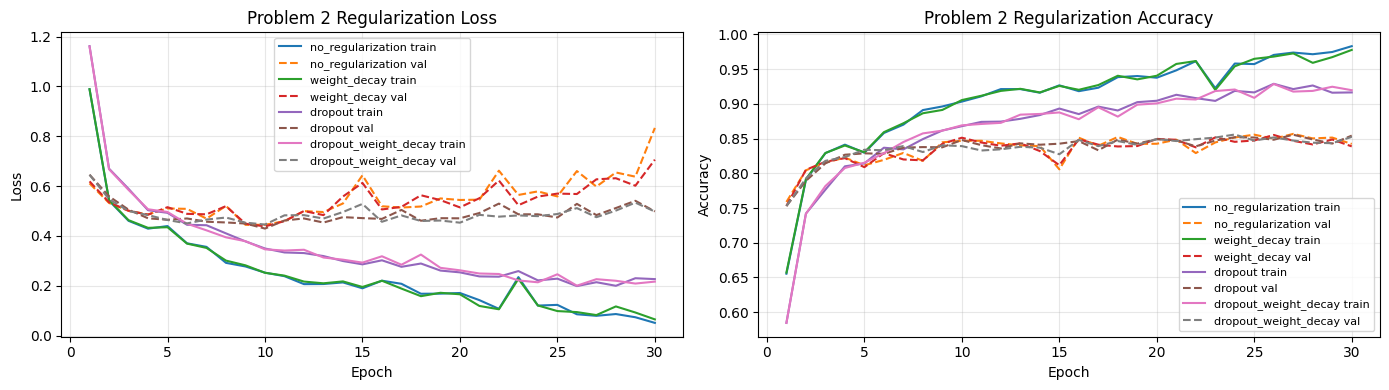

Saved: results_hw02/problem2_summary.json
{
  "no_regularization": {
    "best_epoch": 27,
    "best_val_accuracy": 0.8567,
    "test_accuracy_at_best_val": 0.8485,
    "final_train_loss": 0.0508022224187851,
    "final_val_loss": 0.8333096357345581,
    "final_train_accuracy": 0.983,
    "final_val_accuracy": 0.8422,
    "final_accuracy_gap": 0.14080000000000004,
    "estimated_overfitting_onset_epoch": 8
  },
  "weight_decay": {
    "best_epoch": 26,
    "best_val_accuracy": 0.8552,
    "test_accuracy_at_best_val": 0.8489,
    "final_train_loss": 0.06484519490003586,
    "final_val_loss": 0.705987638092041,
    "final_train_accuracy": 0.9776,
    "final_val_accuracy": 0.8387,
    "final_accuracy_gap": 0.13890000000000002
  },
  "dropout": {
    "best_epoch": 27,
    "best_val_accuracy": 0.8555,
    "test_accuracy_at_best_val": 0.8526,
    "final_train_loss": 0.2265169799566269,
    "final_val_loss": 0.49813748998641966,
    "final_train_accuracy": 0.9164,
    "final_val_accuracy": 0.

In [8]:
def plot_metric_comparison(
    results: dict[str, dict],
    title: str,
    filename: str,
) -> None:
    if not results:
        print("No results to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for run_name, result in results.items():
        history = result["history"]
        epochs = [entry["epoch"] for entry in history]
        axes[0].plot(
            epochs,
            [entry["train_loss"] for entry in history],
            linestyle="-",
            label=f"{run_name} train",
        )
        axes[0].plot(
            epochs,
            [entry["val_loss"] for entry in history],
            linestyle="--",
            label=f"{run_name} val",
        )
        axes[1].plot(
            epochs,
            [entry["train_accuracy"] for entry in history],
            linestyle="-",
            label=f"{run_name} train",
        )
        axes[1].plot(
            epochs,
            [entry["val_accuracy"] for entry in history],
            linestyle="--",
            label=f"{run_name} val",
        )

    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(output_dir / filename, dpi=150)
    plt.show()


def detect_overfitting_onset(
    history: list[dict],
    min_accuracy_gap: float = 0.05,
    min_val_loss_increase: float = 0.01,
) -> int | None:
    best_val_loss = float("inf")
    best_val_epoch = 0

    for entry in history:
        epoch = entry["epoch"]
        val_loss = entry["val_loss"]
        accuracy_gap = entry["train_accuracy"] - entry["val_accuracy"]

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_epoch = epoch
            continue

        val_loss_increase = val_loss - best_val_loss
        if accuracy_gap >= min_accuracy_gap and val_loss_increase >= min_val_loss_increase:
            return max(best_val_epoch + 1, epoch)

    return None


def summarize_final_metrics(results: dict[str, dict]) -> dict[str, dict]:
    summary: dict[str, dict] = {}
    for run_name, result in results.items():
        final_entry = result["history"][-1]
        summary[run_name] = {
            "best_epoch": result["best_epoch"],
            "best_val_accuracy": result["best_val_accuracy"],
            "test_accuracy_at_best_val": result["test_accuracy_at_best_val"],
            "final_train_loss": final_entry["train_loss"],
            "final_val_loss": final_entry["val_loss"],
            "final_train_accuracy": final_entry["train_accuracy"],
            "final_val_accuracy": final_entry["val_accuracy"],
            "final_accuracy_gap": final_entry["train_accuracy"] - final_entry["val_accuracy"],
        }
    return summary


if RUN_PROBLEM_2 and problem2_results:
    plot_metric_comparison(
        problem2_results,
        title="Problem 2 Regularization",
        filename="problem2_regularization_curves.png",
    )

    no_reg_onset = detect_overfitting_onset(problem2_results["no_regularization"]["history"])
    problem2_summary = summarize_final_metrics(problem2_results)
    problem2_summary["no_regularization"]["estimated_overfitting_onset_epoch"] = no_reg_onset

    save_json(problem2_summary, output_dir / "problem2_summary.json")
    print(json.dumps(problem2_summary, indent=2, ensure_ascii=False))

    if no_reg_onset is None:
        print("No regularization 조건에서 명확한 overfitting 시작 epoch가 탐지되지 않았다.")
    else:
        print(f"No regularization 조건의 추정 overfitting 시작 epoch: {no_reg_onset}")



===== no_regularization_20000 =====
Structure: 784 -> 512 -> 256 -> 128 -> 10
Activation: relu
Dropout: 0.0
Optimizer: adam
Learning rate: 0.001
Weight decay: 0.0
Scheduler: none
Trainable parameters: 567434
[no_regularization_20000] Epoch 01/30 | lr=0.001000 | train_loss=0.6194, train_acc=0.7780 | val_loss=0.4897, val_acc=0.8230
[no_regularization_20000] Epoch 02/30 | lr=0.001000 | train_loss=0.4149, train_acc=0.8489 | val_loss=0.4307, val_acc=0.8440
[no_regularization_20000] Epoch 03/30 | lr=0.001000 | train_loss=0.3582, train_acc=0.8681 | val_loss=0.3917, val_acc=0.8536
[no_regularization_20000] Epoch 04/30 | lr=0.001000 | train_loss=0.3211, train_acc=0.8813 | val_loss=0.3794, val_acc=0.8610
[no_regularization_20000] Epoch 05/30 | lr=0.001000 | train_loss=0.3014, train_acc=0.8893 | val_loss=0.3818, val_acc=0.8623
[no_regularization_20000] Epoch 06/30 | lr=0.001000 | train_loss=0.2823, train_acc=0.8929 | val_loss=0.3990, val_acc=0.8594
[no_regularization_20000] Epoch 07/30 | lr=0.00

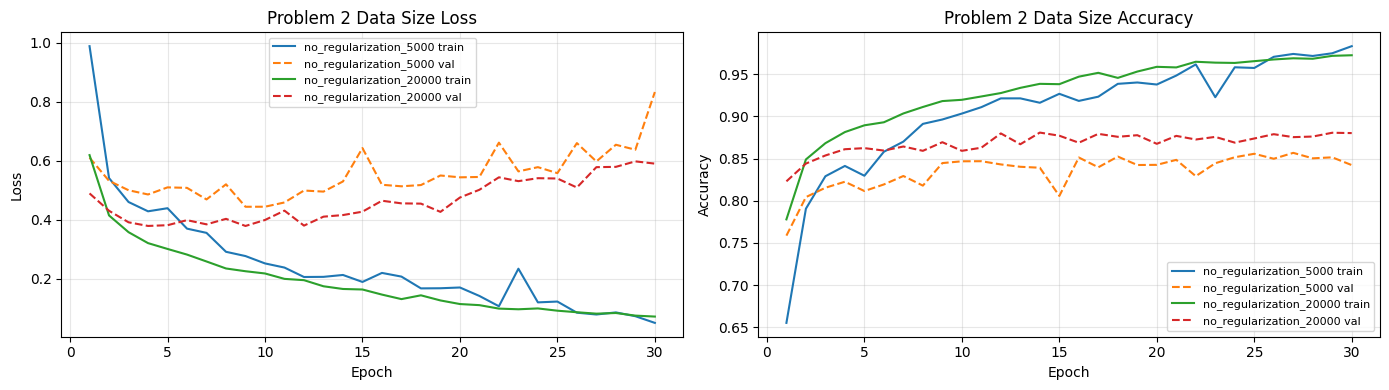

Saved: results_hw02/problem2_data_size_summary.json
{
  "no_regularization_5000": {
    "best_epoch": 27,
    "best_val_accuracy": 0.8567,
    "test_accuracy_at_best_val": 0.8485,
    "final_train_loss": 0.0508022224187851,
    "final_val_loss": 0.8333096357345581,
    "final_train_accuracy": 0.983,
    "final_val_accuracy": 0.8422,
    "final_accuracy_gap": 0.14080000000000004
  },
  "no_regularization_20000": {
    "best_epoch": 14,
    "best_val_accuracy": 0.8807,
    "test_accuracy_at_best_val": 0.8694,
    "final_train_loss": 0.07221789277791978,
    "final_val_loss": 0.5905591148376464,
    "final_train_accuracy": 0.97225,
    "final_val_accuracy": 0.8801,
    "final_accuracy_gap": 0.09214999999999995
  }
}

분석 가이드
- 5,000장 조건에서 train accuracy만 높고 validation accuracy가 정체되면 데이터 부족으로 인한 overfitting이다.
- 20,000장 조건에서 train-validation gap이 줄면 학습 데이터 증가가 regularization처럼 generalization을 개선한 것이다.


In [9]:
data_size_results: dict[str, dict] = {}

if RUN_PROBLEM_2 and problem2_results:
    # Reuse the 5,000-sample no-regularization result and change only train data size.
    data_size_results["no_regularization_5000"] = problem2_results["no_regularization"]

    data_size_config = {
        **problem2_configs["no_regularization"],
        "changed_variable": "train_size=20000",
    }
    data_size_results["no_regularization_20000"] = run_controlled_training(
        name="no_regularization_20000",
        config=data_size_config,
        train_indices=large_train_indices,
        val_indices=validation_indices,
        record_gradients=False,
        data_seed_offset=250,
    )

    plot_metric_comparison(
        data_size_results,
        title="Problem 2 Data Size",
        filename="problem2_data_size_curves.png",
    )
    data_size_summary = summarize_final_metrics(data_size_results)
    save_json(data_size_summary, output_dir / "problem2_data_size_summary.json")
    print(json.dumps(data_size_summary, indent=2, ensure_ascii=False))

    print("\n분석 가이드")
    print("- 5,000장 조건에서 train accuracy만 높고 validation accuracy가 정체되면 데이터 부족으로 인한 overfitting이다.")
    print("- 20,000장 조건에서 train-validation gap이 줄면 학습 데이터 증가가 regularization처럼 generalization을 개선한 것이다.")


## 문제 3. Optimizer 비교 실험

목표: optimizer만 바꾸고 수렴 속도와 최종 성능을 비교한다.

통제 조건:

- 모델 구조 동일: `784 -> 512 -> 256 -> 128 -> 10`
- activation 동일: ReLU
- regularization 없음
- learning rate 동일: 0.005
- train/validation split 동일
- epoch, batch size 동일

Scheduler 비교는 optimizer 비교와 섞지 않기 위해 별도 실험으로 둔다. Adam과 Adam + cosine scheduler만 비교하고, optimizer와 initial learning rate는 동일하게 유지한다.


In [10]:
problem3_shared_config = {
    "hidden_dims": BASE_HIDDEN_DIMS,
    "activation": "relu",
    "dropout": 0.0,
    "weight_decay": 0.0,
    "learning_rate": 0.005,
    "scheduler": "none",
    "epochs": 25,
    "batch_size": 128,
    "model_seed": BASE_SEED,
}

problem3_optimizer_configs = {
    "sgd": {
        **problem3_shared_config,
        "optimizer": "sgd",
        "momentum": 0.0,
        "changed_variable": "optimizer=sgd",
    },
    "sgd_momentum": {
        **problem3_shared_config,
        "optimizer": "sgd",
        "momentum": 0.9,
        "changed_variable": "optimizer=sgd, momentum=0.9",
    },
    "adagrad": {
        **problem3_shared_config,
        "optimizer": "adagrad",
        "momentum": 0.0,
        "changed_variable": "optimizer=adagrad",
    },
    "adam": {
        **problem3_shared_config,
        "optimizer": "adam",
        "momentum": 0.0,
        "changed_variable": "optimizer=adam",
    },
}

problem3_optimizer_results: dict[str, dict] = {}

if RUN_PROBLEM_3:
    for run_name, run_config in problem3_optimizer_configs.items():
        problem3_optimizer_results[run_name] = run_controlled_training(
            name=run_name,
            config=run_config,
            train_indices=small_train_indices,
            val_indices=validation_indices,
            record_gradients=False,
            data_seed_offset=300,
        )

    save_json(problem3_optimizer_results, output_dir / "problem3_optimizer_results.json")
else:
    print("Problem 3 run is disabled.")



===== sgd =====
Structure: 784 -> 512 -> 256 -> 128 -> 10
Activation: relu
Dropout: 0.0
Optimizer: sgd
Learning rate: 0.005
Weight decay: 0.0
Scheduler: none
Trainable parameters: 567434
[sgd] Epoch 01/25 | lr=0.005000 | train_loss=2.2884, train_acc=0.1574 | val_loss=2.2754, val_acc=0.2026
[sgd] Epoch 02/25 | lr=0.005000 | train_loss=2.2620, train_acc=0.2556 | val_loss=2.2472, val_acc=0.3074
[sgd] Epoch 03/25 | lr=0.005000 | train_loss=2.2317, train_acc=0.3370 | val_loss=2.2140, val_acc=0.3818
[sgd] Epoch 04/25 | lr=0.005000 | train_loss=2.1949, train_acc=0.4146 | val_loss=2.1721, val_acc=0.4486
[sgd] Epoch 05/25 | lr=0.005000 | train_loss=2.1472, train_acc=0.4644 | val_loss=2.1171, val_acc=0.4695
[sgd] Epoch 06/25 | lr=0.005000 | train_loss=2.0842, train_acc=0.4878 | val_loss=2.0441, val_acc=0.4944
[sgd] Epoch 07/25 | lr=0.005000 | train_loss=2.0014, train_acc=0.5072 | val_loss=1.9499, val_acc=0.5064
[sgd] Epoch 08/25 | lr=0.005000 | train_loss=1.8966, train_acc=0.5160 | val_loss=1.8


===== adam_cosine_scheduler =====
Structure: 784 -> 512 -> 256 -> 128 -> 10
Activation: relu
Dropout: 0.0
Optimizer: adam
Learning rate: 0.005
Weight decay: 0.0
Scheduler: cosine
Trainable parameters: 567434
[adam_cosine_scheduler] Epoch 01/25 | lr=0.005000 | train_loss=0.9547, train_acc=0.6464 | val_loss=0.6662, val_acc=0.7614
[adam_cosine_scheduler] Epoch 02/25 | lr=0.004980 | train_loss=0.5690, train_acc=0.7856 | val_loss=0.5333, val_acc=0.8126
[adam_cosine_scheduler] Epoch 03/25 | lr=0.004921 | train_loss=0.4709, train_acc=0.8264 | val_loss=0.5177, val_acc=0.8172
[adam_cosine_scheduler] Epoch 04/25 | lr=0.004824 | train_loss=0.3864, train_acc=0.8520 | val_loss=0.6102, val_acc=0.7827
[adam_cosine_scheduler] Epoch 05/25 | lr=0.004691 | train_loss=0.3944, train_acc=0.8524 | val_loss=0.5110, val_acc=0.8322
[adam_cosine_scheduler] Epoch 06/25 | lr=0.004523 | train_loss=0.3656, train_acc=0.8578 | val_loss=0.5022, val_acc=0.8326
[adam_cosine_scheduler] Epoch 07/25 | lr=0.004322 | train_l

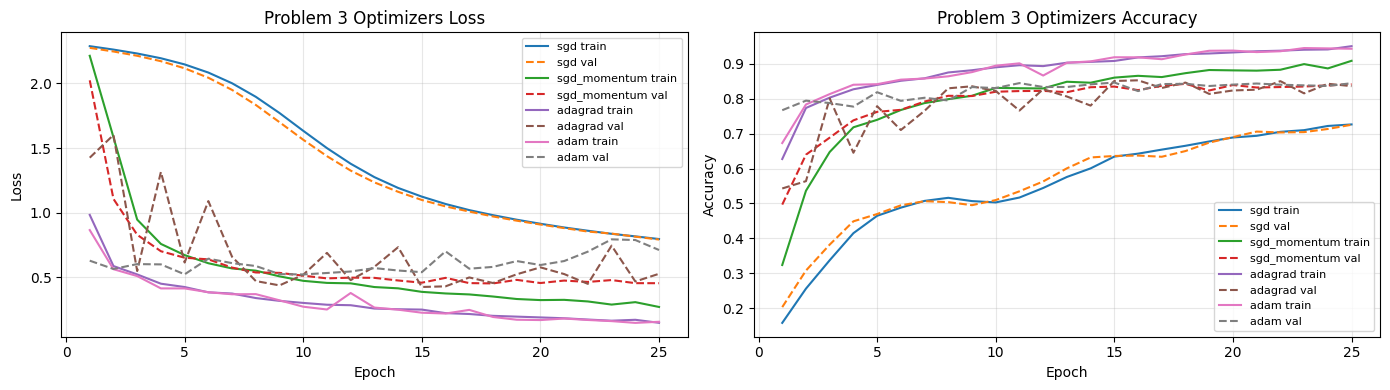

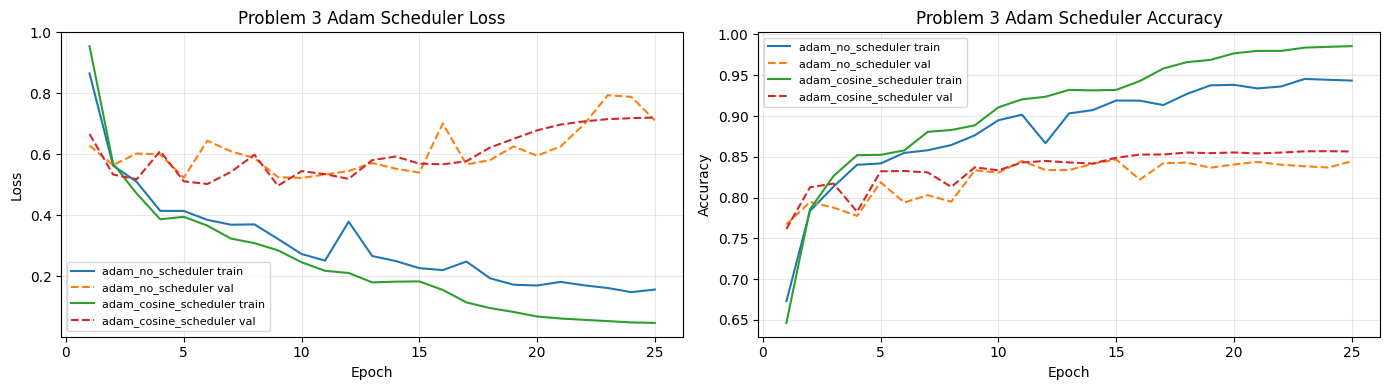

Saved: results_hw02/problem3_optimizer_summary.json
Saved: results_hw02/problem3_scheduler_summary.json
Optimizer summary
{
  "sgd": {
    "best_epoch": 25,
    "best_val_accuracy": 0.7255,
    "test_accuracy_at_best_val": 0.7156,
    "final_train_loss": 0.7960206953048706,
    "final_val_loss": 0.792144323348999,
    "final_train_accuracy": 0.7264,
    "final_val_accuracy": 0.7255,
    "final_accuracy_gap": 0.0009000000000000119
  },
  "sgd_momentum": {
    "best_epoch": 18,
    "best_val_accuracy": 0.8428,
    "test_accuracy_at_best_val": 0.8277,
    "final_train_loss": 0.2703281056404114,
    "final_val_loss": 0.45422493624687194,
    "final_train_accuracy": 0.9088,
    "final_val_accuracy": 0.8417,
    "final_accuracy_gap": 0.06710000000000005
  },
  "adagrad": {
    "best_epoch": 16,
    "best_val_accuracy": 0.8529,
    "test_accuracy_at_best_val": 0.8466,
    "final_train_loss": 0.14766525020599366,
    "final_val_loss": 0.5271532722949982,
    "final_train_accuracy": 0.9508,
   

In [11]:
problem3_scheduler_results: dict[str, dict] = {}

if RUN_PROBLEM_3 and problem3_optimizer_results:
    problem3_scheduler_results["adam_no_scheduler"] = problem3_optimizer_results["adam"]
    adam_cosine_config = {
        **problem3_optimizer_configs["adam"],
        "scheduler": "cosine",
        "changed_variable": "scheduler=cosine",
    }
    problem3_scheduler_results["adam_cosine_scheduler"] = run_controlled_training(
        name="adam_cosine_scheduler",
        config=adam_cosine_config,
        train_indices=small_train_indices,
        val_indices=validation_indices,
        record_gradients=False,
        data_seed_offset=350,
    )

    plot_metric_comparison(
        problem3_optimizer_results,
        title="Problem 3 Optimizers",
        filename="problem3_optimizer_curves.png",
    )
    plot_metric_comparison(
        problem3_scheduler_results,
        title="Problem 3 Adam Scheduler",
        filename="problem3_scheduler_curves.png",
    )

    optimizer_summary = summarize_final_metrics(problem3_optimizer_results)
    scheduler_summary = summarize_final_metrics(problem3_scheduler_results)
    save_json(optimizer_summary, output_dir / "problem3_optimizer_summary.json")
    save_json(scheduler_summary, output_dir / "problem3_scheduler_summary.json")
    print("Optimizer summary")
    print(json.dumps(optimizer_summary, indent=2, ensure_ascii=False))
    print("Scheduler summary")
    print(json.dumps(scheduler_summary, indent=2, ensure_ascii=False))

    print("\n분석 가이드")
    print("- 같은 learning rate에서 validation accuracy가 빨리 상승하는 optimizer가 수렴 속도가 빠른 조건이다.")
    print("- scheduler 비교에서는 Adam과 Adam+cosine만 비교하므로 optimizer 효과와 scheduler 효과가 섞이지 않는다.")


## 문제 4. 최종 모델 구성 및 팀 내 비교

아래 final model은 문제 1~3에서 일반적으로 기대되는 결론을 반영한 후보이다.

- 깊은 Sigmoid 대신 ReLU를 사용한다.
- 작은 학습셋에서 overfitting을 줄이기 위해 Dropout과 Weight decay를 함께 적용한다.
- optimizer는 Adam을 사용하고, learning rate는 cosine scheduler로 후반부에 낮춘다.
- 최종 모델은 validation split을 제외한 train split 전체를 사용한다.

팀원 결과는 현재 노트북에 없으므로 아래 template에 팀원별 최종 모델과 성능을 채워 비교한다.


In [12]:
final_model_config = {
    "hidden_dims": BASE_HIDDEN_DIMS,
    "activation": "relu",
    "dropout": 0.3,
    "weight_decay": 1e-4,
    "optimizer": "adam",
    "momentum": 0.0,
    "learning_rate": 0.001,
    "scheduler": "cosine",
    "epochs": 25,
    "batch_size": 128,
    "model_seed": BASE_SEED,
    "changed_variable": "final_combination_after_controlled_experiments",
}

final_model_result: dict | None = None

if RUN_FINAL_MODEL:
    final_model_result = run_controlled_training(
        name="final_model",
        config=final_model_config,
        train_indices=full_train_indices,
        val_indices=validation_indices,
        record_gradients=False,
        data_seed_offset=400,
    )
    save_json({"final_model": final_model_result}, output_dir / "problem4_final_model_result.json")
else:
    print("Final model run is disabled.")


team_comparison_template = [
    {
        "member": "me",
        "model_structure": model_structure_string(final_model_config["hidden_dims"]),
        "activation": final_model_config["activation"],
        "regularization": "dropout=0.3, weight_decay=1e-4",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "validation_accuracy": None if final_model_result is None else final_model_result["best_val_accuracy"],
        "test_accuracy": None if final_model_result is None else final_model_result["test_accuracy_at_best_val"],
    },
    {
        "member": "teammate_1",
        "model_structure": "",
        "activation": "",
        "regularization": "",
        "optimizer": "",
        "scheduler": "",
        "validation_accuracy": None,
        "test_accuracy": None,
    },
]

save_json({"team_comparison_template": team_comparison_template}, output_dir / "problem4_team_comparison_template.json")
print(json.dumps(team_comparison_template, indent=2, ensure_ascii=False))



===== final_model =====
Structure: 784 -> 512 -> 256 -> 128 -> 10
Activation: relu
Dropout: 0.3
Optimizer: adam
Learning rate: 0.001
Weight decay: 0.0001
Scheduler: cosine
Trainable parameters: 567434
[final_model] Epoch 01/25 | lr=0.001000 | train_loss=0.5889, train_acc=0.7867 | val_loss=0.4111, val_acc=0.8477
[final_model] Epoch 02/25 | lr=0.000996 | train_loss=0.4190, train_acc=0.8479 | val_loss=0.3761, val_acc=0.8672
[final_model] Epoch 03/25 | lr=0.000984 | train_loss=0.3830, train_acc=0.8607 | val_loss=0.3635, val_acc=0.8632
[final_model] Epoch 04/25 | lr=0.000965 | train_loss=0.3601, train_acc=0.8697 | val_loss=0.3716, val_acc=0.8618
[final_model] Epoch 05/25 | lr=0.000938 | train_loss=0.3403, train_acc=0.8754 | val_loss=0.3398, val_acc=0.8772
[final_model] Epoch 06/25 | lr=0.000905 | train_loss=0.3285, train_acc=0.8805 | val_loss=0.3415, val_acc=0.8779
[final_model] Epoch 07/25 | lr=0.000864 | train_loss=0.3152, train_acc=0.8853 | val_loss=0.3315, val_acc=0.8815
[final_model] 

## 문제 5. 실험 회고 및 고찰 초안

### 모델 성능에 큰 영향을 미친 변화

깊은 MLP에서는 activation 변화가 gradient flow에 직접적인 영향을 준다. Sigmoid는 앞쪽 layer의 gradient norm이 매우 작아질 수 있고, 이는 깊은 구조에서 학습이 잘 진행되지 않는 원인이 된다. ReLU는 양수 영역에서 gradient가 유지되므로 Sigmoid보다 앞쪽 layer까지 gradient가 전달되기 쉽다.

학습 데이터가 5,000장으로 줄어든 조건에서는 regularization과 데이터 수가 generalization에 큰 영향을 준다. No regularization 조건에서 train accuracy는 계속 증가하지만 validation loss가 증가하거나 validation accuracy가 정체되면 overfitting으로 해석할 수 있다. Weight decay는 weight 크기를 제한하고, Dropout은 특정 feature 조합에 과도하게 의존하는 것을 줄여 train-validation gap을 완화할 수 있다.

Optimizer도 수렴 속도에 큰 영향을 준다. 같은 learning rate에서 SGD, momentum SGD, AdaGrad, Adam의 validation curve를 비교하면 초기 수렴 속도와 최종 성능 차이를 확인할 수 있다.

### 상대적으로 영향이 작거나 조건부인 변화

Regularization 강도가 너무 약하거나 epoch 수가 짧으면 Weight decay와 Dropout의 차이가 작게 보일 수 있다. 반대로 regularization이 너무 강하면 train 성능 자체가 낮아질 수 있다. 따라서 regularization의 효과는 학습 데이터 크기, 모델 capacity, 학습 epoch와 함께 해석해야 한다.

### 모델을 개선한다는 것의 의미

모델 개선은 train accuracy만 높이는 것이 아니라 validation/test 성능이 재현 가능하게 좋아지는 방향으로 bias, variance, optimization을 조정하는 것이다. 특히 이번 과제에서는 변인을 하나씩 통제해야 어떤 변경이 실제로 성능 변화에 기여했는지 설명할 수 있다.

### 과제 1 대비 LLM 활용 방식 변화

지난 과제에서는 LLM이 제안한 여러 변경 사항을 한 번에 적용해 hidden layer, activation, learning rate, normalization의 효과가 섞였다. 이번 과제에서는 LLM을 코드 생성 도구뿐 아니라 실험 설계 검토 도구로 사용했다. 각 문제에서 독립변인과 통제변인을 먼저 정의하고, 결과 저장과 그래프 생성도 조건별로 분리해 해석 가능성을 높였다.
